Portfolio Return: 28.38%
Sharpe Ratio: 1.03


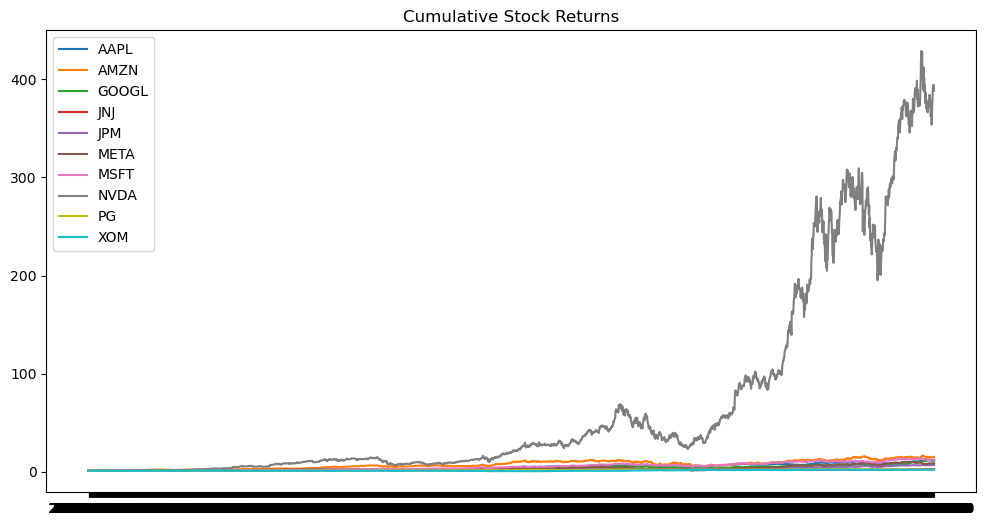

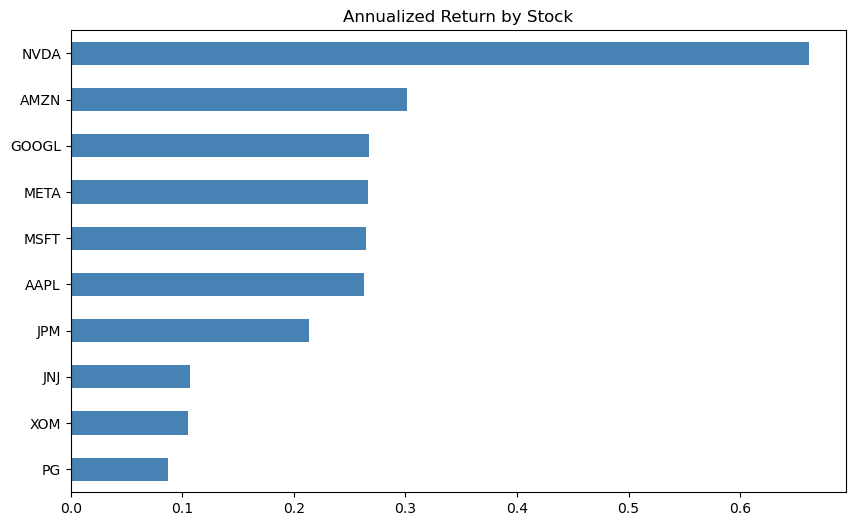

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('/Users/vanshikahooda/Desktop/Portfolio analyzer/Prices.csv')

# Calculate daily returns
returns = df.set_index('Date').pct_change().dropna()

# Portfolio weights
weights = np.array([0.15, 0.10, 0.10, 0.10, 0.10, 0.15, 0.15, 0.10, 0.05, 0.05])

# Annual returns
ann_returns = returns.mean() * 252

# Portfolio return
port_return = np.dot(weights, ann_returns)
print(f"Portfolio Return: {port_return:.2%}")

# Sharpe Ratio
sharpe = (port_return - 0.045) / (returns @ weights).std() / np.sqrt(252)
print(f"Sharpe Ratio: {sharpe:.2f}")

# Chart 1 - Cumulative returns
cumulative_returns = (1 + returns).cumprod()
plt.figure(figsize=(12, 6))
for column in cumulative_returns.columns:
    plt.plot(cumulative_returns.index, cumulative_returns[column], label=column)
plt.title('Cumulative Stock Returns')
plt.legend()
plt.show()

# Chart 2 - Bar chart
plt.figure(figsize=(10, 6))
ann_returns.sort_values().plot(kind='barh', color='steelblue')
plt.title('Annualized Return by Stock')
plt.show()